In [1]:
# Cài đặt các thư viện cần thiết
!pip install -q mediapipe==0.10.30 tensorflow pandas opencv-python tqdm

# # Tạo cấu trúc thư mục cho dự án StaticSL
# !mkdir -p models data/hybrid_manifest checkpoints
# !mkdir -p data/raw/asl_alphabet  # Nơi bạn sẽ upload bộ ảnh ASL gốc vào

# # Tải mô hình Hand Landmarker của Google
# !wget -q -O models/hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 6.7 MB/s eta 0:00:00


In [2]:
import os
import sys
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition"  # đổi lại nếu chạy local
os.chdir(PROJECT_ROOT)

# if PROJECT_ROOT not in sys.path:
#     sys.path.append(PROJECT_ROOT)

# Chuyển working directory về thư mục gốc để các đường dẫn tương đối (data/...) hoạt động đúng
# os.chdir(PROJECT_ROOT)

print(f"Thư mục làm việc hiện tại: {os.getcwd()}")
# Kết quả mong đợi: /.../sign-language-recognition

Mounted at /content/drive
Thư mục làm việc hiện tại: /content/drive/MyDrive/ComputerVision/BTL/sign-language-recognition


In [3]:
import tensorflow as tf
from configs.config import PreprocessConfig
from src.preprocessing.prepare_hybrid_dataset import build_manifest
from src.utils.dataset_split import split_dataset
from src.models.model2_hybrid_transformer_cnn.dataset import LandmarkHybridDataset
from src.models.model2_hybrid_transformer_cnn.model import build_landmark_hybrid_model, compile_model

# Tải cấu hình mặc định từ config.py
cfg = PreprocessConfig()

# (Tuỳ chọn) Ghi đè các thông số nếu muốn test nhanh
# cfg.hybrid.epochs = 10
# cfg.hybrid.batch_size = 32

print(f"Sử dụng Model Asset: {cfg.mediapipe.model_asset_path}")

Sử dụng Model Asset: src/models/hand_landmarker.task


In [4]:
# Tạo thư mục chứa file CSV nếu chưa có
!mkdir -p data/landmarks

# Chạy script trích xuất điểm mốc từ ảnh gốc
!python -m src.preprocessing.extract_landmarks \
    --mode images \
    --input_dir data/raw/asl-alphabet/asl_alphabet_train \
    --output_csv data/landmarks/landmarks_raw.csv

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1789149141.133417    4959 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789149141.204875    4958 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
[extract_landmarks] Label A:   0% 0/3000 [00:00<?, ?it/s]W0000 00:00:1789149142.416327    4958 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
[extract_landmarks] Label A: 100% 3000/3000 [03:32<00:00, 14.11it/s]
[extract_landmarks] Label B: 100% 3000/3000 [03:15<00:00, 15.32it/s]
[extract_landmarks] Label C: 100% 3000/3000 [03:09<00:00, 15.82it/s]
[extract_landmarks] Label D: 100% 3000/3000 [03:30<00:00, 14.27it/s]
[extract_landmarks] Label E: 100% 3000/30

In [4]:
import pandas as pd
cfg = PreprocessConfig()

print("Đọc file tọa độ điểm mốc...")
df_landmarks = pd.read_csv("data/landmarks/landmarks_raw.csv")

# Lọc bỏ các dòng MediaPipe bị miss (nếu script có lưu các dòng lỗi)
df_landmarks = df_landmarks.dropna(subset=['r0'])

# Chia tập dữ liệu
train_df, val_df, test_df = split_dataset(df_landmarks, cfg.split)

os.makedirs(cfg.hybrid_manifest_dir, exist_ok=True)
train_df.to_csv(cfg.hybrid_train_manifest, index=False)
val_df.to_csv(cfg.hybrid_val_manifest, index=False)
test_df.to_csv(cfg.hybrid_test_manifest, index=False)

print(f"Tổng số mẫu hợp lệ: {len(df_landmarks)}")
print(f"Phân bổ Train/Val/Test: {len(train_df)} / {len(val_df)} / {len(test_df)}")

Đọc file tọa độ điểm mốc...
Tổng số mẫu hợp lệ: 59698
Phân bổ Train/Val/Test: 41788 / 8955 / 8955


In [5]:
class_labels = cfg.hybrid.hybrid_class_labels
num_classes = len(class_labels)

print("Đang nạp LandmarkHybridDataset...")
train_ds = LandmarkHybridDataset(
    csv_path=cfg.hybrid_train_manifest, # Sửa 'manifest_csv' thành 'csv_path'
    cfg=cfg,
    class_labels=class_labels,
    training=True # Bật Jittering Augmentation
)

val_ds = LandmarkHybridDataset(
    csv_path=cfg.hybrid_val_manifest,   # Sửa 'manifest_csv' thành 'csv_path'
    cfg=cfg,
    class_labels=class_labels,
    training=False # Tắt Augmentation
)

# Kiểm tra shape của batch đầu tiên
X_batch, y_batch = train_ds[0]
print(f"Input batch shape: {X_batch.shape}")
print(f"Label batch shape: {y_batch.shape}")

Đang nạp LandmarkHybridDataset...
Input batch shape: (64, 21, 3)
Label batch shape: (64, 29)


In [6]:
# 1. Build Model
model = build_landmark_hybrid_model(cfg.hybrid, num_classes)

# 2. Compile Model (Tối ưu AdamW + Cosine Decay)
model = compile_model(model, cfg.hybrid, steps_per_epoch=len(train_ds))
model.summary()

# 3. Cấu hình Callbacks lưu checkpoint vào thư mục /checkpoints/
os.makedirs(os.path.dirname(cfg.hybrid_checkpoint_path), exist_ok=True)
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        cfg.hybrid_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=cfg.hybrid.early_stopping_patience,
        restore_best_weights=True,
        verbose=1
    ),
]

# 4. Fit Model
print("\nBắt đầu huấn luyện...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=cfg.hybrid.epochs,
    callbacks=callbacks,
)

# 5. Dọn dẹp tài nguyên MediaPipe
train_ds.close()
val_ds.close()

Model: "Landmark_Hybrid_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ landmark_input      │ (None, 21, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1d_1 (Conv1D)    │ (None, 21, 32)    │        320 │ landmark_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ joint_embedding     │ (None, 21, 128)   │        512 │ landmark_input[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1d_1            │ (None, 10, 32)    │          0 │ cnn1d_1[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 21, 128)   │          0 │ joint_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn1d_2 (Conv1D)    │ (None, 10, 64)    │      6,208 │ pool1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 21, 128)   │    132,480 │ add[0][0]         │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_gap             │ (None, 64)        │          0 │ cnn1d_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 21, 128)   │    132,480 │ transformer_bloc… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dense (Dense)   │ (None, 128)       │      8,320 │ cnn_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vit_gap             │ (None, 128)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion_ele… │ (None, 128)       │          0 │ cnn_dense[0][0],  │
│ (Multiply)          │                   │            │ vit_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_hidden (Dense)   │ (None, 128)       │     16,512 │ feature_fusion_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_dropout          │ (None, 128)       │          0 │ fc_hidden[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_head │ (None, 29)        │      3,741 │ fc_dropout[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 300,573 (1.15 MB)

 Trainable params: 300,573 (1.15 MB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện...
Epoch 1/60
651/653 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2269 - loss: 2.6364
Epoch 1: val_loss improved from None to 0.61077, saving model to checkpoints/model2_hybrid_transformer_cnn_best.keras

Epoch 1: finished saving model to checkpoints/model2_hybrid_transformer_cnn_best.keras
653/653 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.3789 - loss: 1.9438 - val_accuracy: 0.8096 - val_loss: 0.6108
Epoch 2/60
650/653 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7560 - loss: 0.6710
Epoch 2: val_loss improved from 0.61077 to 0.25592, saving model to checkpoints/model2_hybrid_transformer_cnn_best.keras

Epoch 2: finished saving model to checkpoints/model2_hybrid_transformer_cnn_best.keras
653/653 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8046 - loss: 0.5411 - val_accuracy: 0.9155 - val_loss: 0.2559
Epoch 3/60
649/653 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8832 - loss: 0.3326
Epoch 3: val_loss improved from 0.25592 to 0.17250, saving mode

AttributeError: 'LandmarkHybridDataset' object has no attribute 'close'

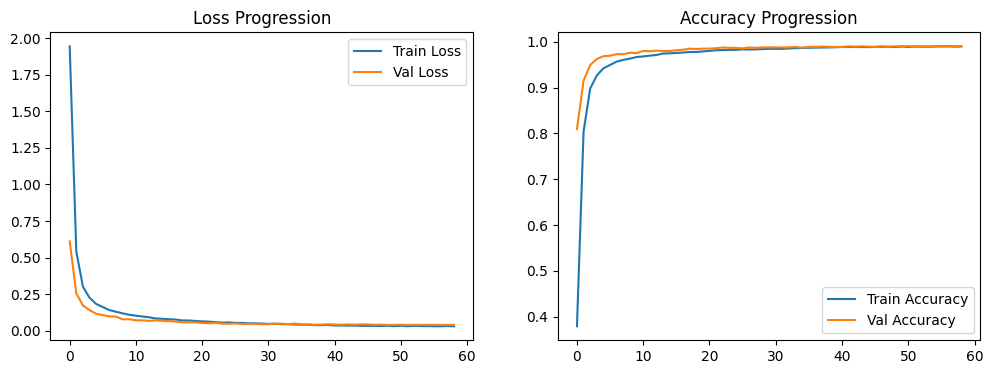

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Progression')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Progression')

plt.show()